Кущенко Валерия, дз 1 по NLP

In [1]:
from __future__ import annotations
import seaborn as sns
import hashlib
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import nltk
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from string import punctuation
from datasets import load_dataset, Dataset
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn

from transformers import AutoModel, Trainer, TrainingArguments
from transformers import AutoTokenizer

import matplotlib.pyplot as plt


DATASET = "Tobi-Bueck/customer-support-tickets"


def read_idx(path: Path) -> np.ndarray:
    arr = np.loadtxt(path, dtype=np.int64)
    return arr


def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()


def split_df(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    data_dir=Path("data")
    train_idx = read_idx(data_dir / "train_idx.txt")
    val_idx = read_idx( data_dir/ "val_idx.txt")
    test_idx = read_idx( data_dir/ "test_idx.txt")

    out = {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }
    return out


In [2]:
import re
import os
import math
import random
import warnings
warnings.filterwarnings("ignore")

from nltk.tokenize import word_tokenize
from nltk import tokenize
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

random.seed(42)
np.random.seed(42)

print("✅ Готово")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


✅ Готово


In [ ]:
from nltk.corpus import stopwords
from string import punctuation

In [ ]:
ru_stop = set(stopwords.words("german"))
en_stop = set(stopwords.words("english"))
punct = set(punctuation)

In [ ]:
print("Loading dataset:", DATASET)
ds = load_dataset(DATASET)["train"]
df = ds.to_pandas()

Loading dataset: Tobi-Bueck/customer-support-tickets


In [ ]:
df.head(1)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None


в качестве базы для обучения будем использовать комбинацию subject + type

In [ ]:
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")
df["type"] = df["type"].fillna(" ")

In [10]:
train_idx = np.loadtxt("data/train_idx.txt", dtype=int)
val_idx = np.loadtxt("data/val_idx.txt", dtype=int)
test_idx = np.loadtxt("data/test_idx.txt", dtype=int)

train = df.loc[train_idx].reset_index(drop=True)
val = df.loc[val_idx].reset_index(drop=True)
test = df.loc[test_idx].reset_index(drop=True)

print("train:", train.shape)
print("val:", val.shape)
print("test:", test.shape)

train: (49412, 17)
val: (6176, 17)
test: (6177, 17)


проанализируем получившиеся данные на длины тикетов, дубликаты, распределение классов и тд

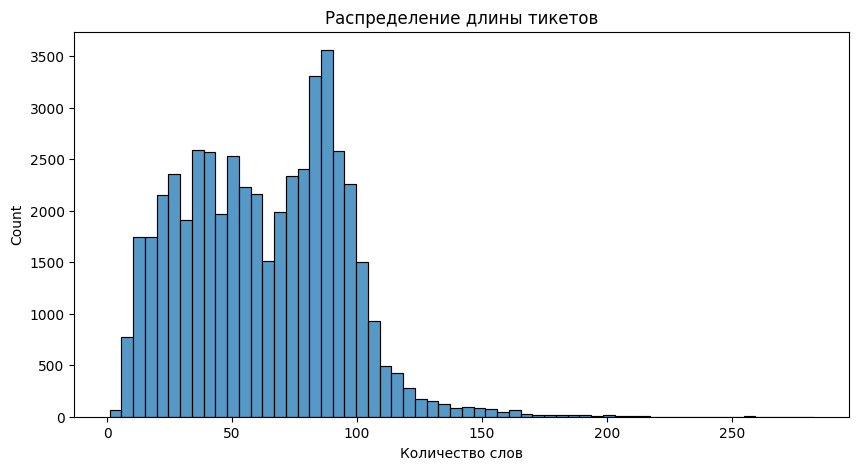

In [ ]:
for d in [train, val, test]:

    d["char_len"] = d["text"].str.len()
    d["word_len"] = d["text"].str.split().apply(len)

plt.figure(figsize=(10,5))

sns.histplot(train["word_len"], bins=60)

plt.title("Распределение длины тикетов")
plt.xlabel("Количество слов")

plt.show()

In [ ]:
print(train["word_len"].describe())

print("\Квантили")

print(train["word_len"].quantile([0.5,0.9,0.95,0.99]))

count    49412.000000
mean        62.445438
std         31.205693
min          1.000000
25%         37.000000
50%         62.000000
75%         87.000000
max        283.000000
Name: word_len, dtype: float64
\Квантили
0.50     62.0
0.90     99.0
0.95    108.0
0.99    143.0
Name: word_len, dtype: float64


In [ ]:
queue_counts = train["queue"].value_counts()

print("Количество классов в queue:", train["queue"].nunique())

display(queue_counts.head(20))

Количество классов в queue: 52


queue
Technical Support                      11354
Product Support                         7139
Customer Service                        5905
IT Support                              4673
Billing and Payments                    3853
Returns and Exchanges                   1956
Service Outages and Maintenance         1534
Sales and Pre-Sales                     1228
Human Resources                          730
General Inquiry                          532
News                                     313
Pets & Animals/Pet Services              308
Autos & Vehicles/Sales                   287
Home & Garden/Home Improvement           285
IT & Technology/Security Operations      285
Shopping/E-commerce                      278
Health/Medical Services                  278
Pets & Animals/Veterinary Care           278
Health/Mental Health                     275
Jobs & Education/Online Courses          271
Name: count, dtype: int64

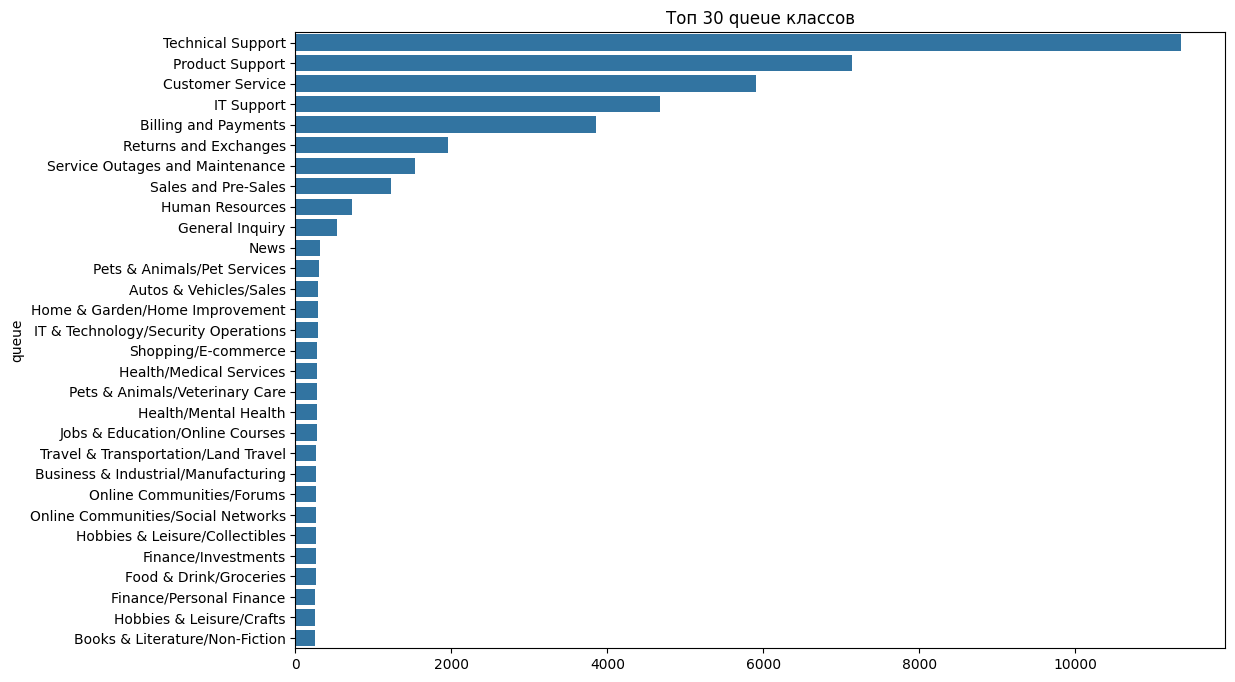

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    y=queue_counts.index[:30],
    x=queue_counts.values[:30]
)

plt.title("Tоп 30 queue классов")

plt.show()

priority
medium      18629
high        17546
low         10280
critical     1516
very_low     1441
Name: count, dtype: int64

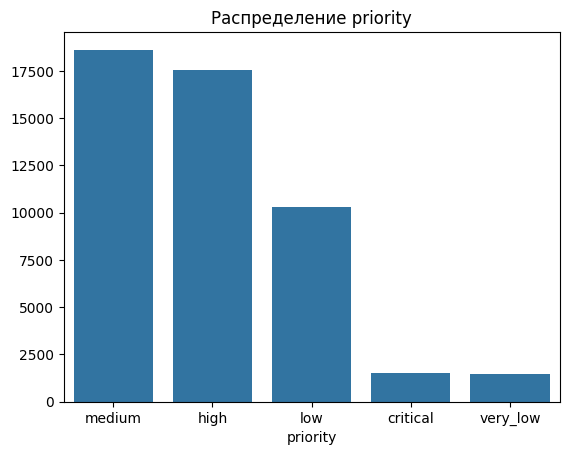

In [ ]:
priority_counts = train["priority"].value_counts()

display(priority_counts)

sns.barplot(
    x=priority_counts.index,
    y=priority_counts.values
)

plt.title("Pаспределение priority")

plt.show()

type
Incident    15632
Request     11165
            10508
Problem      8103
Change       4004
Name: count, dtype: int64

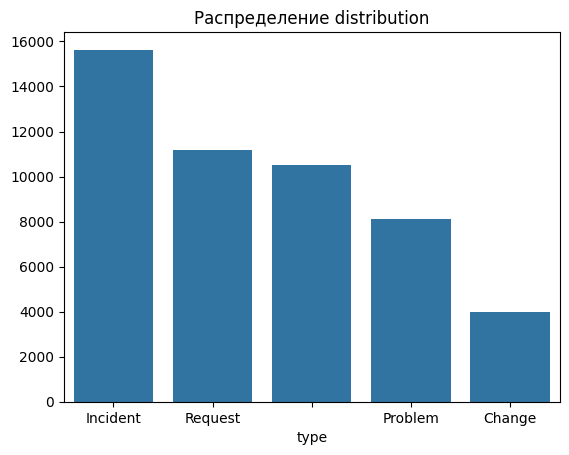

In [ ]:
type_counts = train["type"].value_counts()

display(type_counts)

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Pаспределение distribution")

plt.show()

видим, что есть неопознанный класс - пустые значения

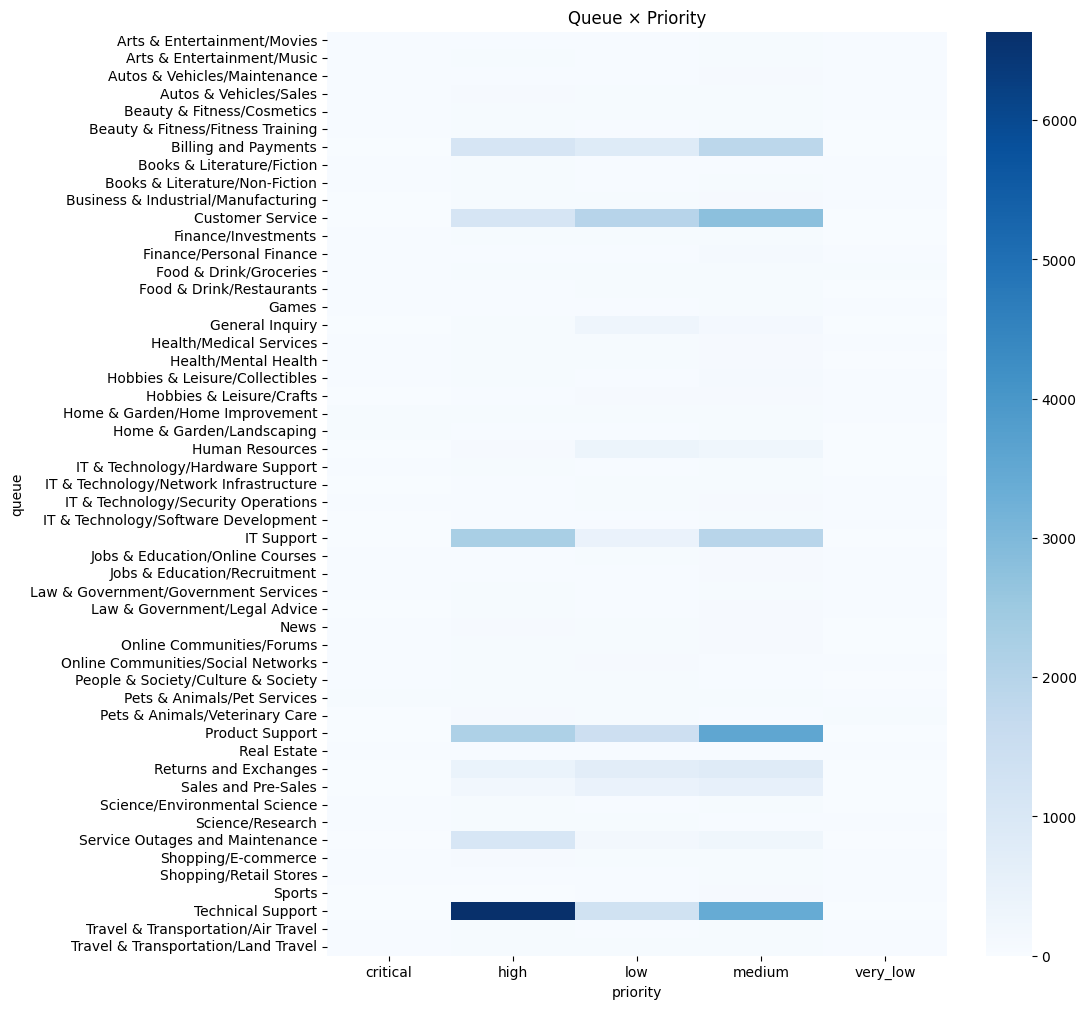

In [ ]:
queue_priority = pd.crosstab(
    train["queue"],
    train["priority"]
)

plt.figure(figsize=(10,12))

sns.heatmap(
    queue_priority,
    cmap="Blues"
)

plt.title("Queue × Priority")

plt.show()

в целом то, что у technical support обычно самый высокий приоритет, выглядит логично (но держим в уме то, что это самый большой класс)

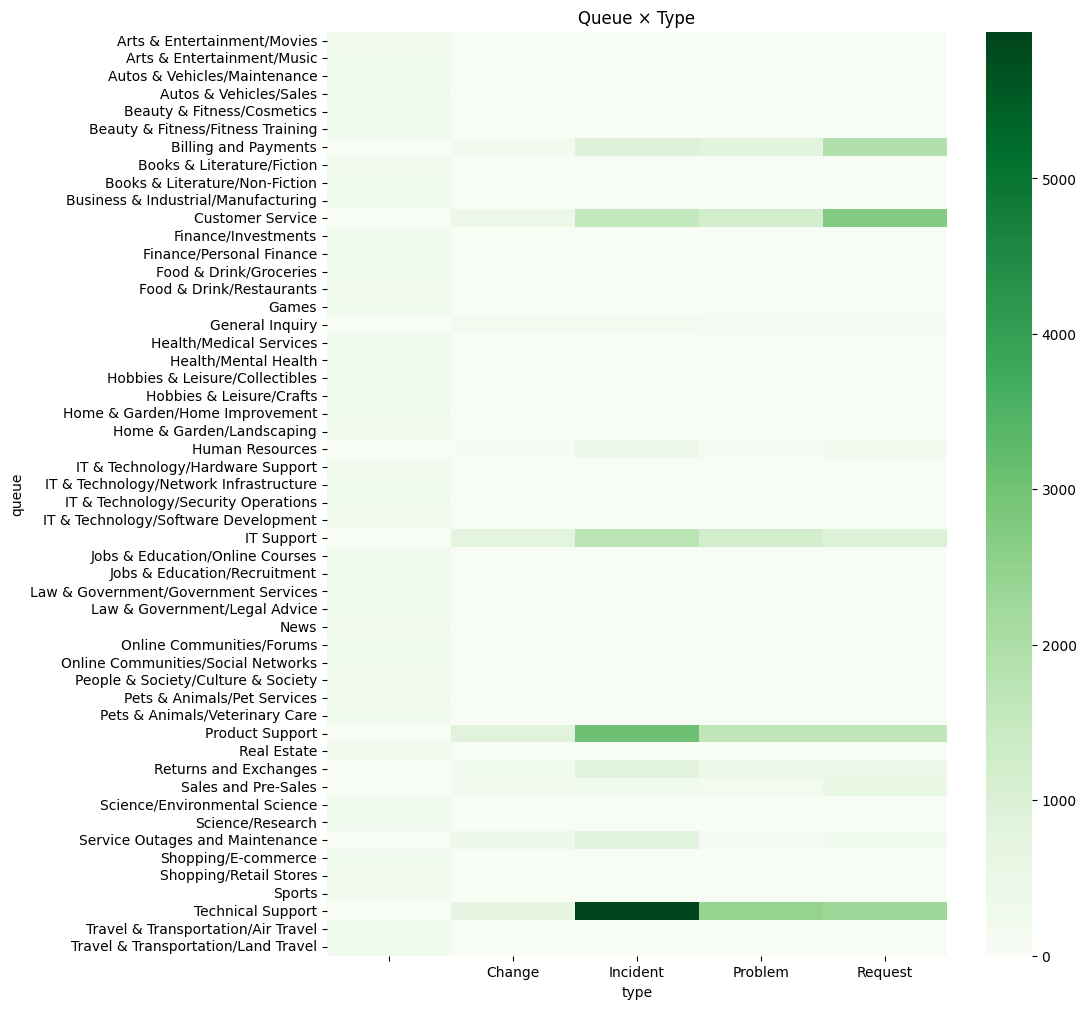

In [ ]:
queue_type = pd.crosstab(
    train["queue"],
    train["type"]
)

plt.figure(figsize=(10,12))

sns.heatmap(
    queue_type,
    cmap="Greens"
)

plt.title("Queue × Type")

plt.show()

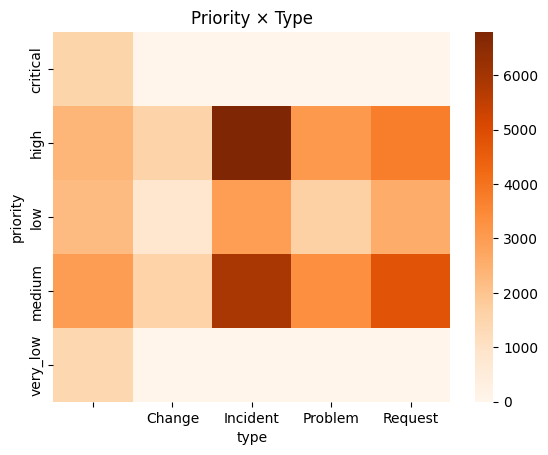

In [ ]:
priority_type = pd.crosstab(
    train["priority"],
    train["type"]
)

sns.heatmap(
    priority_type,
    cmap="Oranges"
)

plt.title("Priority × Type")

plt.show()


In [ ]:
train_texts = set(train["text"])
val_texts = set(val["text"])
test_texts = set(test["text"])

print("train ∩ val:", len(train_texts & val_texts))
print("train ∩ test:", len(train_texts & test_texts))
print("val ∩ test:", len(val_texts & test_texts))

train ∩ val: 0
train ∩ test: 0
val ∩ test: 0


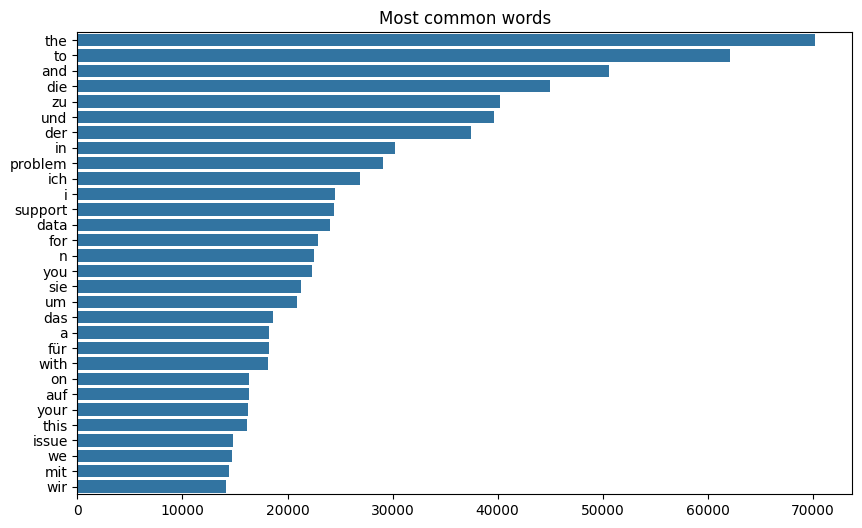

In [ ]:
text = " ".join(train["text"])

words = re.findall(r"\w+", text.lower())

counter = Counter(words)

top_words = counter.most_common(30)

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(10,6))

sns.barplot(x=counts, y=words)

plt.title("Most common words")

plt.show()

самые частые слова похожи на стоп-слова. так что в экспериментах надо будет попробоваь удалить английские и немецкие стоп-слова

In [ ]:
train["text_hash"] = (
    train["subject"].fillna("") + " " + train["body"].fillna("")
).str.lower().str.strip()

dup_mask = train["text_hash"].duplicated(keep=False)

duplicates = train[dup_mask].copy()

print("Total duplicated rows:", len(duplicates))
print("Unique duplicated texts:", duplicates["text_hash"].nunique())

Total duplicated rows: 13329
Unique duplicated texts: 6664


In [ ]:
duplicates[
    ["subject", "queue", "priority", "type","text_hash"]
].sort_values("text_hash").head(20)

dup_groups = duplicates.groupby("text_hash").agg({
    "queue": pd.Series.nunique,
    "priority": pd.Series.nunique,
    "type": pd.Series.nunique
}).reset_index()

dup_groups.head()

,text_hash,queue,priority,type
0,-issue with file upload size users are encount...,1,1,1
1,15. oktober zeigten sich störungen bei design-...,1,1,1
2,a data breach has been detected at a healthcar...,1,1,1
3,a data breach has been identified in healthcar...,1,1,1
4,"a data breach has taken place, potentially end...",1,1,1


In [ ]:
print("Conflicts in queue:", (dup_groups["queue"] > 1).sum())
print("Conflicts in priority:", (dup_groups["priority"] > 1).sum())
print("Conflicts in type:", (dup_groups["type"] > 1).sum())

Conflicts in queue: 0
Conflicts in priority: 0
Conflicts in type: 0


делаем вывод, что в дубликатах нет несовпадения классов

In [ ]:
train['language'].value_counts(normalize=True)

language
de    0.542358
en    0.457642
Name: proportion, dtype: float64

In [ ]:
nltk.download("stopwords")

tokenizer = WordPunctTokenizer()

ge_stop = set(stopwords.words("german"))
en_stop = set(stopwords.words("english"))
punct = set(punctuation)

noise = ge_stop | en_stop | punct

all_tokens = []

for text in train["text_hash"].dropna():
    tokens = tokenizer.tokenize(text)
    clean_tokens = [
        t.lower()
        for t in tokens
        if t.lower() not in noise and t.isalpha()
    ]
    all_tokens.extend(clean_tokens)

counter = Counter(all_tokens)
print(counter.most_common(20))

[nltk_data] Downloading package stopwords to /Users/alfa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('problem', 29040), ('support', 24430), ('data', 24082), ('n', 22534), ('issue', 14800), ('would', 13130), ('team', 12970), ('software', 12913), ('could', 12182), ('system', 10966), ('integration', 10852), ('unterstützung', 10261), ('information', 10208), ('assistance', 10205), ('customer', 8971), ('security', 8820), ('bitte', 8732), ('könnten', 8691), ('provide', 8690), ('lösung', 8212)]


In [ ]:
print(counter.most_common())

[('problem', 29040), ('support', 24430), ('data', 24082), ('n', 22534), ('issue', 14800), ('would', 13130), ('team', 12970), ('software', 12913), ('could', 12182), ('system', 10966), ('integration', 10852), ('unterstützung', 10261), ('information', 10208), ('assistance', 10205), ('customer', 8971), ('security', 8820), ('bitte', 8732), ('könnten', 8691), ('provide', 8690), ('lösung', 8212), ('analytics', 8149), ('investment', 8119), ('appreciate', 8014), ('please', 7966), ('medical', 7939), ('due', 7864), ('tools', 7853), ('nich', 7741), ('digital', 7417), ('marketing', 6792), ('issues', 6694), ('problems', 6654), ('project', 6438), ('dank', 6146), ('details', 6092), ('saas', 6031), ('updates', 6006), ('informationen', 5793), ('management', 5475), ('might', 5452), ('greatly', 5379), ('name', 5335), ('resolve', 5238), ('daten', 5031), ('schreibe', 4939), ('strategies', 4923), ('systems', 4880), ('probleme', 4827), ('geehrte', 4705), ('recent', 4686), ('request', 4647), ('access', 4628), 

теперь смотрим на самые частые слова за вычетом стоп-слов (англ+немецкий) и пунктуации

In [ ]:
counter

Counter({'problem': 29040,
         'support': 24430,
         'data': 24082,
         'n': 22534,
         'issue': 14800,
         'would': 13130,
         'team': 12970,
         'software': 12913,
         'could': 12182,
         'system': 10966,
         'integration': 10852,
         'unterstützung': 10261,
         'information': 10208,
         'assistance': 10205,
         'customer': 8971,
         'security': 8820,
         'bitte': 8732,
         'könnten': 8691,
         'provide': 8690,
         'lösung': 8212,
         'analytics': 8149,
         'investment': 8119,
         'appreciate': 8014,
         'please': 7966,
         'medical': 7939,
         'due': 7864,
         'tools': 7853,
         'nich': 7741,
         'digital': 7417,
         'marketing': 6792,
         'issues': 6694,
         'problems': 6654,
         'project': 6438,
         'dank': 6146,
         'details': 6092,
         'saas': 6031,
         'updates': 6006,
         'informationen': 5793,


и самые редкие:

In [ ]:
counter.most_common()[-20:]

[('markenwahranstrengungen', 1),
 ('gipfels', 1),
 ('rotations', 1),
 ('newest', 1),
 ('integrationsanpassung', 1),
 ('programmiercodes', 1),
 ('datensicherheitsausfall', 1),
 ('medizindatensicherheitsproblem', 1),
 ('manipulieren', 1),
 ('verträglich', 1),
 ('mitte', 1),
 ('analysenprozesses', 1),
 ('forecasted', 1),
 ('eingerichtete', 1),
 ('nbis', 1),
 ('notch', 1),
 ('barriere', 1),
 ('realzeite', 1),
 ('gesamtportfolioleistung', 1),
 ('implementierungszeiträume', 1)]

implementierungszeiträume выглядит как заклинание из гарри поттера

## Преоразуем train

дедуплицируем выборку (удалим дубликаты)

In [ ]:
print("Train size before dedup:", train.shape)
train = train.drop_duplicates(subset="text_hash").reset_index(drop=True)
print("Train size after dedup:", train.shape)

Train size before dedup: (49412, 20)
Train size after dedup: (42747, 20)


## Linear + TF-IDF

газ обучаться

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

results = []

def log_experiment(name, model, X_train, y_train, X_val, y_val, X_test=None, y_test=None):

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)

    val_macro_f1 = f1_score(y_val, val_pred, average="macro")
    val_acc = accuracy_score(y_val, val_pred)

    result = {
        "experiment": name,
        "val_macro_f1": val_macro_f1,
        "val_acc": val_acc
    }

    if X_test is not None:
        test_pred = model.predict(X_test)

        result["test_macro_f1"] = f1_score(y_test, test_pred, average="macro")
        result["test_acc"] = accuracy_score(y_test, test_pred)

    results.append(result)

    print(name)
    print("Val Macro-F1:", round(val_macro_f1,4))
    print("Val Acc:", round(val_acc,4))

    if X_test is not None:
        print("Test Macro-F1:", round(result["test_macro_f1"],4))
        print("Test Acc:", round(result["test_acc"],4))

    print()

In [ ]:
val["text_hash"] = (
    val["subject"].fillna("") + " " + val["body"].fillna("")
).str.lower().str.strip()

test["text_hash"] = (
    test["subject"].fillna("") + " " + test["body"].fillna("")
).str.lower().str.strip()

X_train = train["text_hash"]
y_train = train["queue"]

X_val = val["text_hash"]
y_val = val["queue"]

X_test = test["text_hash"]
y_test = test["queue"]

логика экспериментов - сначала начинаю с некой базы, потом как в графе влево-вправо пытаюсь поменять какие-то параметры. если есть улучшение - двигаюсь в эту сторону (либо результаты экспериментов +- одинаковы то могу двигаться от них обоих)

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=50000,
        min_df=3
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

log_experiment(
    "TFIDF(1,2) (50k) + LR",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,2) (50k) + LR
Val Macro-F1: 0.8033
Val Acc: 0.4848
Test Macro-F1: 0.7952
Test Acc: 0.4907



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        max_features=50000,
        min_df=3
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

log_experiment(
    "TFIDF(1,3) (50k) + LR",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3) (50k) + LR
Val Macro-F1: 0.7606
Val Acc: 0.4733
Test Macro-F1: 0.7558
Test Acc: 0.4779



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        max_features=200000,
        min_df=3
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

log_experiment(
    "TFIDF(1,3) (200k) + LR",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3) (200k) + LR
Val Macro-F1: 0.8055
Val Acc: 0.4995
Test Macro-F1: 0.798
Test Acc: 0.5007



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=100_000,
        min_df=3
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

log_experiment(
    "TFIDF(1,2) (100k) + LR",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,2) (100k) + LR
Val Macro-F1: 0.816
Val Acc: 0.4945
Test Macro-F1: 0.8074
Test Acc: 0.4978



теперь вспомним о том, что было много стоп-слов - добавим их учитывание (пока без пунктуации)

чтобы было круто закачаем и английские и немецкие стоп-слова

In [ ]:
from nltk.corpus import stopwords
from string import punctuation

ge_stop = set(stopwords.words("german"))
en_stop = set(stopwords.words("english"))

stop_words = list(ge_stop | en_stop)

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=100000,
        min_df=3,
        stop_words=stop_words
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])
log_experiment(
    "TFIDF(1,2)(100k) + LR + stopwords",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,2)(100k) + LR + stopwords
Val Macro-F1: 0.8314
Val Acc: 0.5112
Test Macro-F1: 0.8195
Test Acc: 0.5053



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        max_features=200000,
        min_df=3,
        stop_words=stop_words
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

log_experiment(
    "TFIDF(1,3)(200k) + LR + stopwords",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3)(200k) + LR + stopwords
Val Macro-F1: 0.8305
Val Acc: 0.5186
Test Macro-F1: 0.8171
Test Acc: 0.5122



окей, попробуем вместо линейки взять свц

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        max_features=200000,
        min_df=3,
        stop_words=stop_words
    )),
    ("clf", LinearSVC())
])

log_experiment(
    "TFIDF(1,3)(200k) + SVC + stopwords",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3)(200k) + SVC + stopwords
Val Macro-F1: 0.9007
Val Acc: 0.7039
Test Macro-F1: 0.8866
Test Acc: 0.6955



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=100000,
        min_df=3,
        stop_words=stop_words
    )),
    ("clf", LinearSVC())
])

log_experiment(
    "TFIDF(1,2)(100k) + SVC + stopwords",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,2)(100k) + SVC + stopwords
Val Macro-F1: 0.8976
Val Acc: 0.6914
Test Macro-F1: 0.891
Test Acc: 0.6846



теперь попробуем в стоп-слова добавить и пунктуацию

In [ ]:
punct = set(punctuation)
ge_stop = set(stopwords.words("german"))
en_stop = set(stopwords.words("english"))

stop_punct_words = list(ge_stop | en_stop | punct)

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        max_features=200000,
        min_df=3,
        stop_words=stop_punct_words
    )),
    ("clf", LinearSVC())
])

log_experiment(
    "TFIDF(1,3)(200k) + SVC + stop_punct",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3)(200k) + SVC + stop_punct
Val Macro-F1: 0.9007
Val Acc: 0.7039
Test Macro-F1: 0.8866
Test Acc: 0.6955



макро ф1 упал, но аккюраси выросла

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=100000,
        min_df=3,
        stop_words=stop_punct_words
    )),
    ("clf", LinearSVC())
])

log_experiment(
    "TFIDF(1,2)(100k) + SVC + stop_punct",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,2)(100k) + SVC + stop_punct
Val Macro-F1: 0.8976
Val Acc: 0.6914
Test Macro-F1: 0.891
Test Acc: 0.6846



попробуем применить лемматизацию

In [ ]:
from pymystem3 import Mystem
import re
mystem = Mystem()

def mystem_tokenize(text):
    text = text.lower()
    lemmas = mystem.lemmatize(text)
    tokens = [lemma.strip() for lemma in lemmas if lemma.strip()]

    return tokens

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=mystem_tokenize,
        token_pattern=None,
        ngram_range=(1,2),
        max_features=100000,
        min_df=3,
        stop_words=stop_punct_words
     )),
    ("clf", LinearSVC())
])

log_experiment(
    "TFIDF(1,2)(100k) + SVC + stop_punct + stem",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,2)(100k) + SVC + stop_punct + stem
Val Macro-F1: 0.8979
Val Acc: 0.6932
Test Macro-F1: 0.8897
Test Acc: 0.684



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=mystem_tokenize,
        token_pattern=None,
        ngram_range=(1,3),
        max_features=200000,
        min_df=3,
        stop_words=stop_punct_words
     )),
    ("clf", LinearSVC())
])

log_experiment(
    "TFIDF(1,3)(200k) + SVC + stop_punct + stem",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3)(200k) + SVC + stop_punct + stem
Val Macro-F1: 0.8995
Val Acc: 0.7027
Test Macro-F1: 0.8878
Test Acc: 0.6958



теперь пробуем менять параметры внутри svc

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=mystem_tokenize,
        token_pattern=None,
        ngram_range=(1,3),
        max_features=200000,
        min_df=3,
        stop_words=stop_punct_words
     )),
    ("clf", LinearSVC(C=2))
])

log_experiment(
    "TFIDF(1,3)(200k) + SVC (C=2) + stop_punct + stem",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3)(200k) + SVC (C=2) + stop_punct + stem
Val Macro-F1: 0.9053
Val Acc: 0.7107
Test Macro-F1: 0.8936
Test Acc: 0.702



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=mystem_tokenize,
        token_pattern=None,
        ngram_range=(1,2),
        max_features=100000,
        min_df=3,
        stop_words=stop_punct_words
     )),
    ("clf", LinearSVC(C=2))
])

log_experiment(
    "TFIDF(1,2)(100k) + SVC(C=2) + stop_punct + stem",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,2)(100k) + SVC(C=2) + stop_punct + stem
Val Macro-F1: 0.9013
Val Acc: 0.6975
Test Macro-F1: 0.8996
Test Acc: 0.691



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=mystem_tokenize,
        token_pattern=None,
        ngram_range=(1,3),
        max_features=200000,
        min_df=3,
        stop_words=stop_punct_words
     )),
    ("clf", LinearSVC(C=3))
])

log_experiment(
    "TFIDF(1,3)(200k) + SVC (C=3) + stop_punct + stem",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3)(200k) + SVC (C=3) + stop_punct + stem
Val Macro-F1: 0.9072
Val Acc: 0.7141
Test Macro-F1: 0.8962
Test Acc: 0.7049



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=mystem_tokenize,
        token_pattern=None,
        ngram_range=(1,2),
        max_features=100000,
        min_df=3,
        stop_words=stop_punct_words
     )),
    ("clf", LinearSVC(C=3))
])

log_experiment(
    "TFIDF(1,2)(100k) + SVC(C=3) + stop_punct + stem",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,2)(100k) + SVC(C=3) + stop_punct + stem
Val Macro-F1: 0.9037
Val Acc: 0.7003
Test Macro-F1: 0.899
Test Acc: 0.691



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=mystem_tokenize,
        token_pattern=None,
        ngram_range=(1,3),
        max_features=200000,
        min_df=3,
        stop_words=stop_punct_words
     )),
    ("clf", LinearSVC(C=4))
])

log_experiment(
    "TFIDF(1,3)(200k) + SVC (C=4) + stop_punct + stem",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3)(200k) + SVC (C=4) + stop_punct + stem
Val Macro-F1: 0.9074
Val Acc: 0.7144
Test Macro-F1: 0.8988
Test Acc: 0.7055



In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=mystem_tokenize,
        token_pattern=None,
        ngram_range=(1,2),
        max_features=100000,
        min_df=3,
        stop_words=stop_punct_words
     )),
    ("clf", LinearSVC(C=3))
])

log_experiment(
    "TFIDF(1,2)(100k) + SVC(C=4) + stop_punct + stem",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,2)(100k) + SVC(C=4) + stop_punct + stem
Val Macro-F1: 0.9037
Val Acc: 0.7003
Test Macro-F1: 0.899
Test Acc: 0.691



изменение типа регуляризации не дало особо прироста

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=mystem_tokenize,
        token_pattern=None,
        ngram_range=(1,3),
        max_features=200000,
        min_df=3,
        stop_words=stop_punct_words
     )),
    ("clf", LinearSVC(C=4, penalty="l1"))
])

log_experiment(
    "TFIDF(1,3)(200k) + SVC (C=4, l1) + stop_punct + stem",
    model,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

TFIDF(1,3)(200k) + SVC (C=4, l1) + stop_punct + stem
Val Macro-F1: 0.8828
Val Acc: 0.6812
Test Macro-F1: 0.868
Test Acc: 0.6662



In [ ]:
results_df = pd.DataFrame(results)

results_df

,experiment,val_macro_f1,val_acc,test_macro_f1,test_acc
0,"TFIDF(1,2) (50k) + LR",0.803344,0.484780,0.795183,0.490691
1,"TFIDF(1,3) (50k) + LR",0.760563,0.473284,0.755757,0.477902
2,"TFIDF(1,3) (200k) + LR",0.805460,0.499514,0.798022,0.500729
3,"TFIDF(1,2) (100k) + LR",0.815990,0.494495,0.807418,0.497814
4,"TFIDF(1,2)(100k) + LR + stopwords",0.831406,0.511172,0.819460,0.505261
5,"TFIDF(1,3)(200k) + LR + stopwords",0.830457,0.518620,0.817060,0.512223
6,"TFIDF(1,3)(200k) + SVC + stopwords",0.900690,0.703854,0.886639,0.695483
7,"TFIDF(1,2)(100k) + SVC + stopwords",0.897639,0.691386,0.891012,0.684637
8,"TFIDF(1,3)(200k) + SVC + stop_punct",0.900690,0.703854,0.886639,0.695483
9,"TFIDF(1,2)(100k) + SVC + stop_punct",0.897639,0.691386,0.891012,0.684637


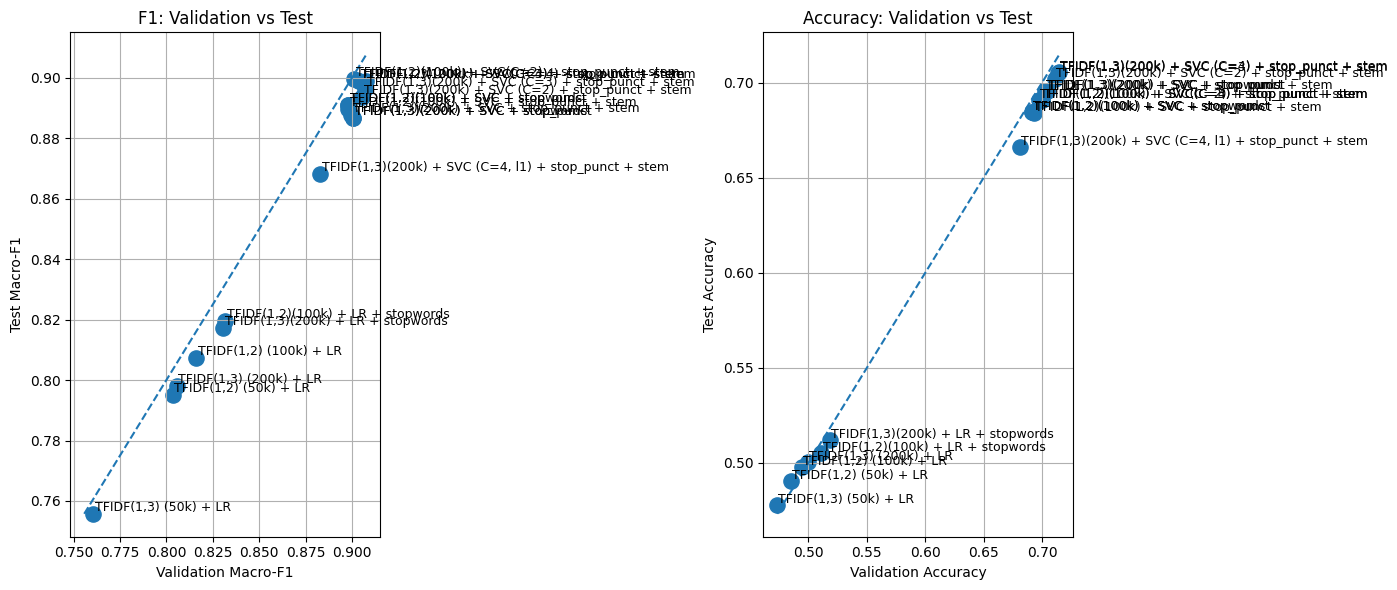

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].scatter(
    results_df["val_macro_f1"],
    results_df["test_macro_f1"],
    s=120
)

for _, row in results_df.iterrows():
    axes[0].text(
        row["val_macro_f1"] + 0.001,
        row["test_macro_f1"] + 0.001,
        row["experiment"],
        fontsize=9
    )

min_v = min(results_df["val_macro_f1"].min(), results_df["test_macro_f1"].min())
max_v = max(results_df["val_macro_f1"].max(), results_df["test_macro_f1"].max())

axes[0].plot([min_v, max_v], [min_v, max_v], linestyle="--")

axes[0].set_xlabel("Validation Macro-F1")
axes[0].set_ylabel("Test Macro-F1")
axes[0].set_title("F1: Validation vs Test")
axes[0].grid(True)

axes[1].scatter(
    results_df["val_acc"],
    results_df["test_acc"],
    s=120
)

for _, row in results_df.iterrows():
    axes[1].text(
        row["val_acc"] + 0.001,
        row["test_acc"] + 0.001,
        row["experiment"],
        fontsize=9
    )

min_v = min(results_df["val_acc"].min(), results_df["test_acc"].min())
max_v = max(results_df["val_acc"].max(), results_df["test_acc"].max())

axes[1].plot([min_v, max_v], [min_v, max_v], linestyle="--")

axes[1].set_xlabel("Validation Accuracy")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Accuracy: Validation vs Test")
axes[1].grid(True)


plt.tight_layout()
plt.show()

ничего не видно в правом уголке - посмотрим поближе

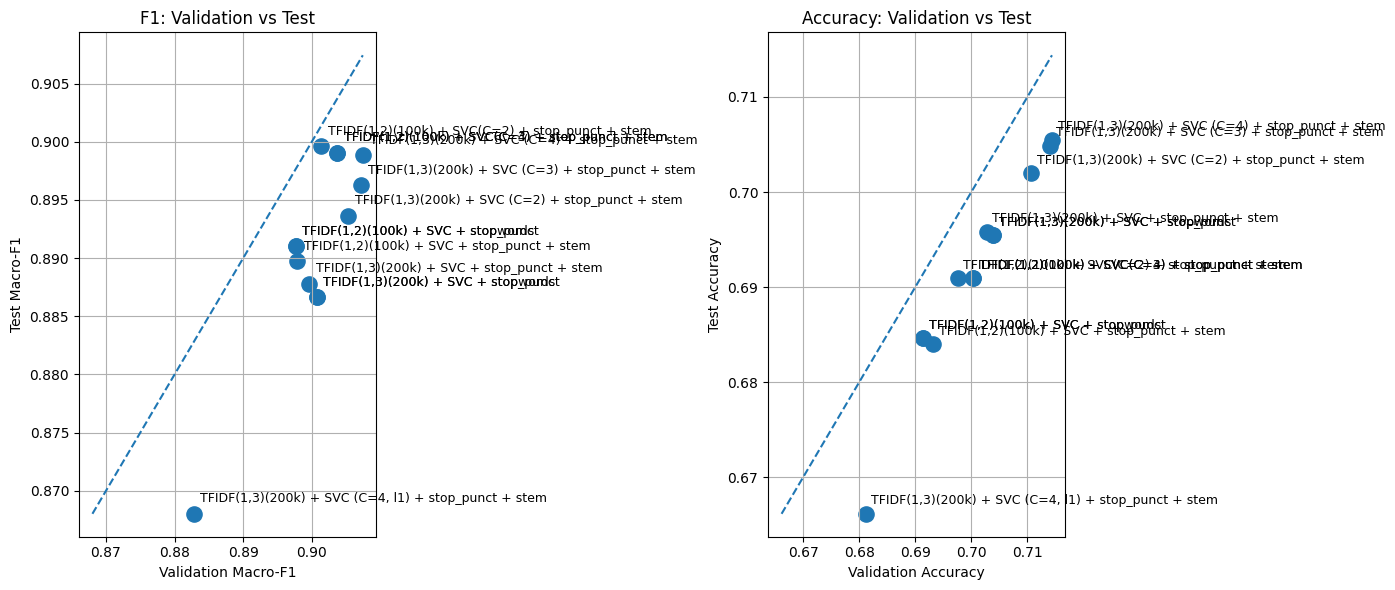

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
results_df_1=results_df[results_df['val_macro_f1']>0.875]
axes[0].scatter(
    results_df_1["val_macro_f1"],
    results_df_1["test_macro_f1"],
    s=120
)

for _, row in results_df_1.iterrows():
    axes[0].text(
        row["val_macro_f1"] + 0.001,
        row["test_macro_f1"] + 0.001,
        row["experiment"],
        fontsize=9
    )

min_v = min(results_df_1["val_macro_f1"].min(), results_df_1["test_macro_f1"].min())
max_v = max(results_df_1["val_macro_f1"].max(), results_df_1["test_macro_f1"].max())

axes[0].plot([min_v, max_v], [min_v, max_v], linestyle="--")

axes[0].set_xlabel("Validation Macro-F1")
axes[0].set_ylabel("Test Macro-F1")
axes[0].set_title("F1: Validation vs Test")
axes[0].grid(True)

axes[1].scatter(
    results_df_1["val_acc"],
    results_df_1["test_acc"],
    s=120
)

for _, row in results_df_1.iterrows():
    axes[1].text(
        row["val_acc"] + 0.001,
        row["test_acc"] + 0.001,
        row["experiment"],
        fontsize=9
    )

min_v = min(results_df_1["val_acc"].min(), results_df_1["test_acc"].min())
max_v = max(results_df_1["val_acc"].max(), results_df_1["test_acc"].max())

axes[1].plot([min_v, max_v], [min_v, max_v], linestyle="--")

axes[1].set_xlabel("Validation Accuracy")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Accuracy: Validation vs Test")
axes[1].grid(True)


plt.tight_layout()
plt.show()

итого лучшая модель: TFIDF(1,3)(200k) + SVC (C=4) + stop_punct + stem

val макро f1 /val acc /test макро f1  / test acc
![image.png](attachment:image.png)

## Transformer

In [3]:
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df = dataset["train"].to_pandas()

df["text"] = (df["subject"].fillna("") + " " + df["body"].fillna("")).str.lower().str.strip()
df["type"] = (df["type"].fillna(" ")).str.lower().str.strip()

train_idx = np.loadtxt("data/train_idx.txt", dtype=int)
val_idx = np.loadtxt("data/val_idx.txt", dtype=int)
test_idx = np.loadtxt("data/test_idx.txt", dtype=int)

train = df.loc[train_idx].reset_index(drop=True)
val = df.loc[val_idx].reset_index(drop=True)
test = df.loc[test_idx].reset_index(drop=True)

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

In [4]:
le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

train["queue_id"] = le_queue.fit_transform(train["queue"])
train["priority_id"] = le_priority.fit_transform(train["priority"])
train["type_id"] = le_type.fit_transform(train["type"])

val["queue_id"] = le_queue.transform(val["queue"])
val["priority_id"] = le_priority.transform(val["priority"])
val["type_id"] = le_type.transform(val["type"])

test["queue_id"] = le_queue.transform(test["queue"])
test["priority_id"] = le_priority.transform(test["priority"])
test["type_id"] = le_type.transform(test["type"])

In [5]:
train_ds = Dataset.from_pandas(
    train[["text","queue_id","priority_id","type_id"]].rename(columns={"text":"input"})
)

val_ds = Dataset.from_pandas(
    val[["text","queue_id","priority_id","type_id"]].rename(columns={"text":"input"})
)

test_ds = Dataset.from_pandas(
    test[["text","queue_id","priority_id","type_id"]].rename(columns={"text":"input"})
)

In [6]:
transformer_results = []

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)


MODEL_NAME = "distilbert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(
        batch["input"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)


cols = [
    "input_ids",
    "attention_mask",
    "queue_id",
    "priority_id",
    "type_id"
]

train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)


# количество классов
n_queue = len(set(train_ds["queue_id"]))
n_priority = len(set(train_ds["priority_id"]))
n_type = len(set(train_ds["type_id"]))


class MultiTaskModel(nn.Module):

    def __init__(self, model_name, n_queue, n_priority, n_type):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)

        hidden = self.encoder.config.hidden_size

        self.queue_head = nn.Linear(hidden, n_queue)
        self.priority_head = nn.Linear(hidden, n_priority)
        self.type_head = nn.Linear(hidden, n_type)

        self.loss_fn = nn.CrossEntropyLoss()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        queue_id=None,
        priority_id=None,
        type_id=None,
    ):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = outputs.last_hidden_state[:, 0]

        q_logits = self.queue_head(cls)
        p_logits = self.priority_head(cls)
        t_logits = self.type_head(cls)

        loss = None

        if queue_id is not None:

            loss_q = self.loss_fn(q_logits, queue_id)
            loss_p = self.loss_fn(p_logits, priority_id)
            loss_t = self.loss_fn(t_logits, type_id)

            loss = loss_q + loss_p + loss_t

        return {
            "loss": loss,
            "logits": (q_logits, p_logits, t_logits)
        }


def compute_metrics(eval_pred):

    logits, labels = eval_pred

    q_logits, p_logits, t_logits = logits
    q_true, p_true, t_true = labels

    q_pred = np.argmax(q_logits, axis=1)
    p_pred = np.argmax(p_logits, axis=1)
    t_pred = np.argmax(t_logits, axis=1)

    queue_macro_f1 = f1_score(q_true, q_pred, average="macro")
    queue_acc = accuracy_score(q_true, q_pred)

    priority_acc = accuracy_score(p_true, p_pred)
    type_acc = accuracy_score(t_true, t_pred)

    final_score = (queue_macro_f1 + priority_acc + type_acc) / 3

    return {
        "queue_macro_f1": queue_macro_f1,
        "queue_acc": queue_acc,
        "priority_acc": priority_acc,
        "type_acc": type_acc,
        "final_score": final_score
    }


transformer_results = []


def run_transformer_experiment(name, lr, epochs, batch):

    model = MultiTaskModel(
        MODEL_NAME,
        n_queue,
        n_priority,
        n_type
    ).to(device)

    args = TrainingArguments(

        output_dir=f"./{name}",

        learning_rate=lr,
        num_train_epochs=epochs,

        per_device_train_batch_size=batch,
        per_device_eval_batch_size=batch,

        weight_decay=0.01,

        eval_strategy="epoch",

        save_strategy="no",

        logging_steps=50,

        label_names=[
            "queue_id",
            "priority_id",
            "type_id"
        ],

        fp16=torch.cuda.is_available(),

        report_to="none"
    )

    trainer = Trainer(

        model=model,
        args=args,

        train_dataset=train_ds,
        eval_dataset=val_ds,

        compute_metrics=compute_metrics
    )

    trainer.train()

    val_metrics = trainer.evaluate()

    test_pred = trainer.predict(test_ds)
    test_metrics = compute_metrics((test_pred.predictions, test_pred.label_ids))

    transformer_results.append({

        "experiment": name,
        "val_score": val_metrics["eval_final_score"],
        "test_score": test_metrics["final_score"]
    })

    print(name)
    print("VAL:", val_metrics["eval_final_score"])
    print("TEST:", test_metrics["final_score"])
    print()


run_transformer_experiment("distilbert_lr2e-5", lr=2e-5, epochs=3, batch=16)
run_transformer_experiment("distilbert_lr1e-5", lr=1e-5, epochs=3, batch=16)
run_transformer_experiment("distilbert_lr3e-5", lr=3e-5, epochs=3, batch=16)
run_transformer_experiment("distilbert_5epochs", lr=2e-5, epochs=5, batch=16)


transformer_results_df = pd.DataFrame(transformer_results)

transformer_results_df.sort_values("val_score", ascending=False)

DEVICE: cuda


Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Queue Macro F1,Queue Acc,Priority Acc,Type Acc,Final Score
1,3.313919,3.272009,0.180885,0.361399,0.558614,0.845855,0.528451
2,2.527360,2.582913,0.697534,0.520887,0.601198,0.866095,0.721609
3,2.180147,2.368550,0.796625,0.563148,0.614637,0.870952,0.760738
4,1.939412,2.294500,0.820899,0.580797,0.651554,0.875486,0.782646
5,1.633417,2.286707,0.832987,0.591969,0.662889,0.878076,0.791317


distilbert_5epochs
VAL: 0.7913171814367224
TEST: 0.7839746295986663



,experiment,val_score,test_score
3,distilbert_5epochs,0.791317,0.783975
2,distilbert_lr3e-5,0.764705,0.763808
0,distilbert_lr2e-5,0.732951,0.730965
1,distilbert_lr1e-5,0.560739,0.550780


In [11]:
transformer_results_df = pd.DataFrame(transformer_results)

transformer_results_df.sort_values("val_score", ascending=False)

,experiment,val_score,test_score
3,distilbert_5epochs,0.791317,0.783975
2,distilbert_lr3e-5,0.764705,0.763808
0,distilbert_lr2e-5,0.732951,0.730965
1,distilbert_lr1e-5,0.560739,0.550780


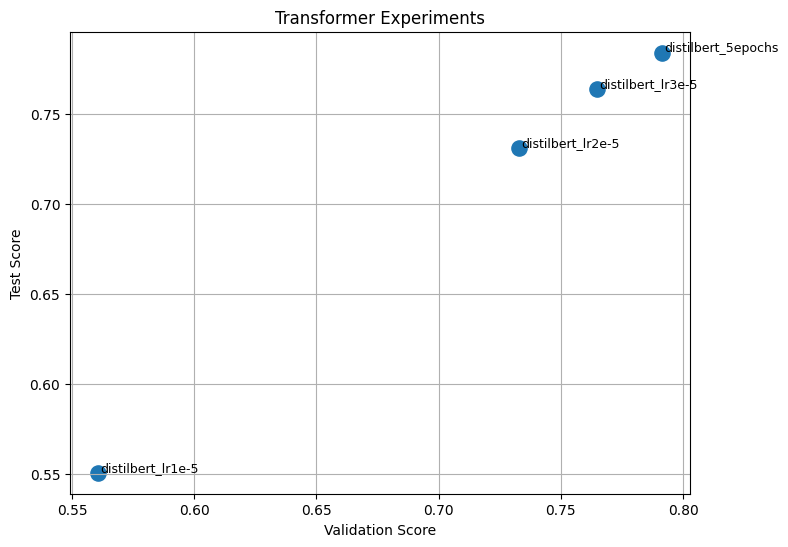

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    transformer_results_df["val_score"],
    transformer_results_df["test_score"],
    s=120
)

for _, row in transformer_results_df.iterrows():
    plt.text(
        row["val_score"] + 0.001,
        row["test_score"] + 0.001,
        row["experiment"],
        fontsize=9
    )

plt.xlabel("Validation Score")
plt.ylabel("Test Score")

plt.title("Transformer Experiments")

plt.grid(True)

plt.show()

больше коллаб почему-то не осилил - делаем выводы отсюда. эпох маловато - надо ставить минимум 5, там после 5 эпох можно как раз и покрутить шаги обучения и тд. на 3-х эпохах 1e-5 шаг слишком маленький, лучше подбирать больше - еще как вариант можно поробовать поставить 0.1, 0.01 и тд